# SOTA Comparison Analysis: Claude 4.5 vs Open-Source Models

This notebook compares frontier Claude models (via OpenRouter) against open-source models on vulnerability detection.

## Models Compared

**SOTA (Closed-Source):**
- Claude Sonnet 4.5 (~70B+ parameters, non-reasoning)
- Claude Opus 4.5 (~200B+ parameters, extended thinking)

**Open-Source:**
- Qwen3-4B-Instruct / Qwen3-4B-Thinking
- Nemotron-Nano-8B (Instruct / Thinking)
- Qwen3-30B-A3B-Instruct / Qwen3-30B-A3B-Thinking
- Nemotron-Super-49B (Instruct / Thinking)

## Task: Vulnerability Detection (VulTrial Dataset)
- 386 C/C++ functions
- Binary classification: vulnerable (1) vs non-vulnerable (0)
- SA (Single-Agent) design - optimal for this task

**Date**: January 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Base paths
from pathlib import Path
BASE_DIR = Path('..').resolve()
RESULTS_DIR = BASE_DIR / 'results'
SOTA_DIR = RESULTS_DIR / 'sota_comparison'
ANALYSIS_DIR = RESULTS_DIR / 'analysis_sota'
ANALYSIS_DIR.mkdir(exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")
print(f"SOTA results: {SOTA_DIR}")
print(f"Analysis output: {ANALYSIS_DIR}")

Results directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results
SOTA results: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/sota_comparison
Analysis output: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_sota


## 1. Load SOTA Results

In [2]:
# Load SOTA results from summary CSV files
sota_results = []

for summary_file in SOTA_DIR.glob('*/*_summary_metrics.csv'):
    # Parse experiment info from directory name
    dir_name = summary_file.parent.name  # e.g., 'SA-few_Claude-Opus-4.5'
    parts = dir_name.split('_')
    design_prompt = parts[0]  # 'SA-few' or 'SA-zero'
    model_name = '_'.join(parts[1:])  # 'Claude-Opus-4.5'
    
    prompting = 'few-shot' if 'few' in design_prompt else 'zero-shot'
    
    # Determine mode based on model
    if 'Opus' in model_name:
        mode = 'thinking'
        params = 200  # Approximate
    else:
        mode = 'instruct'
        params = 70  # Approximate
    
    # Read metrics
    df = pd.read_csv(summary_file)
    row = df.iloc[0]
    
    sota_results.append({
        'model': model_name,
        'model_family': 'Claude',
        'parameters_b': params,
        'design': 'SA',
        'task': 'vulnerability_detection',
        'mode': mode,
        'prompting': prompting,
        'accuracy': row['Accuracy'],
        'precision': row['Precision'],
        'recall': row['Recall'],
        'f1_score': row['F1'],
        'true_positives': row['TP'],
        'true_negatives': row['TN'],
        'false_positives': row['FP'],
        'false_negatives': row['FN'],
        'total_samples': row['Total'],
        'source': 'sota_openrouter'
    })

sota_df = pd.DataFrame(sota_results)
print(f"Loaded {len(sota_df)} SOTA experiments")
sota_df[['model', 'prompting', 'accuracy', 'precision', 'recall', 'f1_score']]

Loaded 4 SOTA experiments


,model,prompting,accuracy,precision,recall,f1_score
0,Claude-Opus-4.5,few-shot,0.559585,0.536050,0.886010,0.667969
1,Claude-Sonnet-4.5,few-shot,0.510363,0.505618,0.932642,0.655738
2,Claude-Opus-4.5,zero-shot,0.536269,0.529915,0.642487,0.580796
3,Claude-Sonnet-4.5,zero-shot,0.497409,0.498534,0.880829,0.636704


## 2. Load Open-Source Results

In [3]:
# Load consolidated performance data
perf_df = pd.read_csv(RESULTS_DIR / 'consolidated_performance.csv')

# Filter to SA vulnerability detection only (matching SOTA experiments)
open_source_df = perf_df[
    (perf_df['task'] == 'vulnerability_detection') & 
    (perf_df['design'] == 'SA')
].copy()

print(f"Open-source SA vulnerability detection experiments: {len(open_source_df)}")
open_source_df[['model', 'parameters_b', 'mode', 'prompting', 'accuracy', 'f1_score']]

Open-source SA vulnerability detection experiments: 16


,model,parameters_b,mode,prompting,accuracy,f1_score
32,Qwen3-4B-Instruct,4,instruct,few-shot,0.523316,0.378378
33,Qwen3-4B-Instruct,4,instruct,zero-shot,0.531088,0.295720
34,Qwen3-4B-Thinking,4,thinking,few-shot,0.525907,0.588764
35,Qwen3-4B-Thinking,4,thinking,zero-shot,0.502591,0.505155
56,Nemotron-Nano-8B,8,instruct,few-shot,0.507772,0.489247
57,Nemotron-Nano-8B,8,instruct,zero-shot,0.507772,0.251969
58,Nemotron-Nano-8B,8,thinking,few-shot,0.489637,0.463215
59,Nemotron-Nano-8B,8,thinking,zero-shot,0.505181,0.180258
92,Qwen3-30B-A3B-Instruct,30,instruct,few-shot,0.562176,0.544474
93,Qwen3-30B-A3B-Instruct,30,instruct,zero-shot,0.541451,0.512397


## 3. Combine All Results

In [4]:
# Combine SOTA and open-source results
# Select common columns
common_cols = ['model', 'model_family', 'parameters_b', 'design', 'task', 'mode', 'prompting',
               'accuracy', 'precision', 'recall', 'f1_score', 
               'true_positives', 'true_negatives', 'false_positives', 'false_negatives']

# Add source column to open-source
open_source_df['source'] = 'open_source'

# Ensure all columns exist
for col in common_cols:
    if col not in sota_df.columns:
        sota_df[col] = None
    if col not in open_source_df.columns:
        open_source_df[col] = None

combined_df = pd.concat([sota_df, open_source_df], ignore_index=True)

# Add derived columns
combined_df['accuracy_pct'] = combined_df['accuracy'] * 100
combined_df['precision_pct'] = combined_df['precision'] * 100
combined_df['recall_pct'] = combined_df['recall'] * 100
combined_df['f1_pct'] = combined_df['f1_score'] * 100

# Create short labels
def make_label(row):
    if row['model_family'] == 'Claude':
        model = 'Sonnet' if 'Sonnet' in row['model'] else 'Opus'
    else:
        model = f"{int(row['parameters_b'])}B"
    mode = 'Thin' if row['mode'] == 'thinking' else 'Inst'
    prompt = 'F' if row['prompting'] == 'few-shot' else 'Z'
    return f"{model} {mode} {prompt}"

combined_df['label'] = combined_df.apply(make_label, axis=1)

print(f"Total experiments: {len(combined_df)}")
combined_df[['label', 'model_family', 'parameters_b', 'accuracy_pct', 'f1_pct', 'recall_pct']].sort_values('f1_pct', ascending=False)

Total experiments: 20


,label,model_family,parameters_b,accuracy_pct,f1_pct,recall_pct
0,Opus Thin F,Claude,200,55.958549,66.796875,88.601036
1,Sonnet Inst F,Claude,70,51.036269,65.573770,93.264249
19,49B Thin Z,Nemotron,49,53.626943,63.983903,82.383420
3,Sonnet Inst Z,Claude,70,49.740933,63.670412,88.082902
18,49B Thin F,Nemotron,49,55.208333,63.247863,77.486911
6,4B Thin F,Qwen,4,52.590674,58.876404,67.875648
2,Opus Thin Z,Claude,200,53.626943,58.079625,64.248705
16,49B Inst F,Nemotron,49,54.404145,57.894737,62.694301
14,30B Thin F,Qwen,30,50.259067,55.555556,62.176166
15,30B Thin Z,Qwen,30,52.590674,54.814815,57.512953


## 4. Comparison Table

In [5]:
# Create formatted comparison table
comparison_table = combined_df[['model', 'parameters_b', 'mode', 'prompting', 
                                 'accuracy_pct', 'precision_pct', 'recall_pct', 'f1_pct']].copy()
comparison_table = comparison_table.sort_values('f1_pct', ascending=False)
comparison_table.columns = ['Model', 'Params (B)', 'Mode', 'Prompting', 
                            'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)']

# Round to 2 decimals
for col in ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)']:
    comparison_table[col] = comparison_table[col].round(2)

print("="*100)
print("SA VULNERABILITY DETECTION: SOTA vs OPEN-SOURCE COMPARISON")
print("="*100)
print(comparison_table.to_string(index=False))

SA VULNERABILITY DETECTION: SOTA vs OPEN-SOURCE COMPARISON
                 Model  Params (B)     Mode Prompting  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)
       Claude-Opus-4.5         200 thinking  few-shot         55.96          53.61       88.60   66.80
     Claude-Sonnet-4.5          70 instruct  few-shot         51.04          50.56       93.26   65.57
    Nemotron-Super-49B          49 thinking zero-shot         53.63          52.30       82.38   63.98
     Claude-Sonnet-4.5          70 instruct zero-shot         49.74          49.85       88.08   63.67
    Nemotron-Super-49B          49 thinking  few-shot         55.21          53.43       77.49   63.25
     Qwen3-4B-Thinking           4 thinking  few-shot         52.59          51.98       67.88   58.88
       Claude-Opus-4.5         200 thinking zero-shot         53.63          52.99       64.25   58.08
    Nemotron-Super-49B          49 instruct  few-shot         54.40          53.78       62.69   57.89
Qwen3-30B-A3B-

## 5. Visualization: F1 Score Comparison

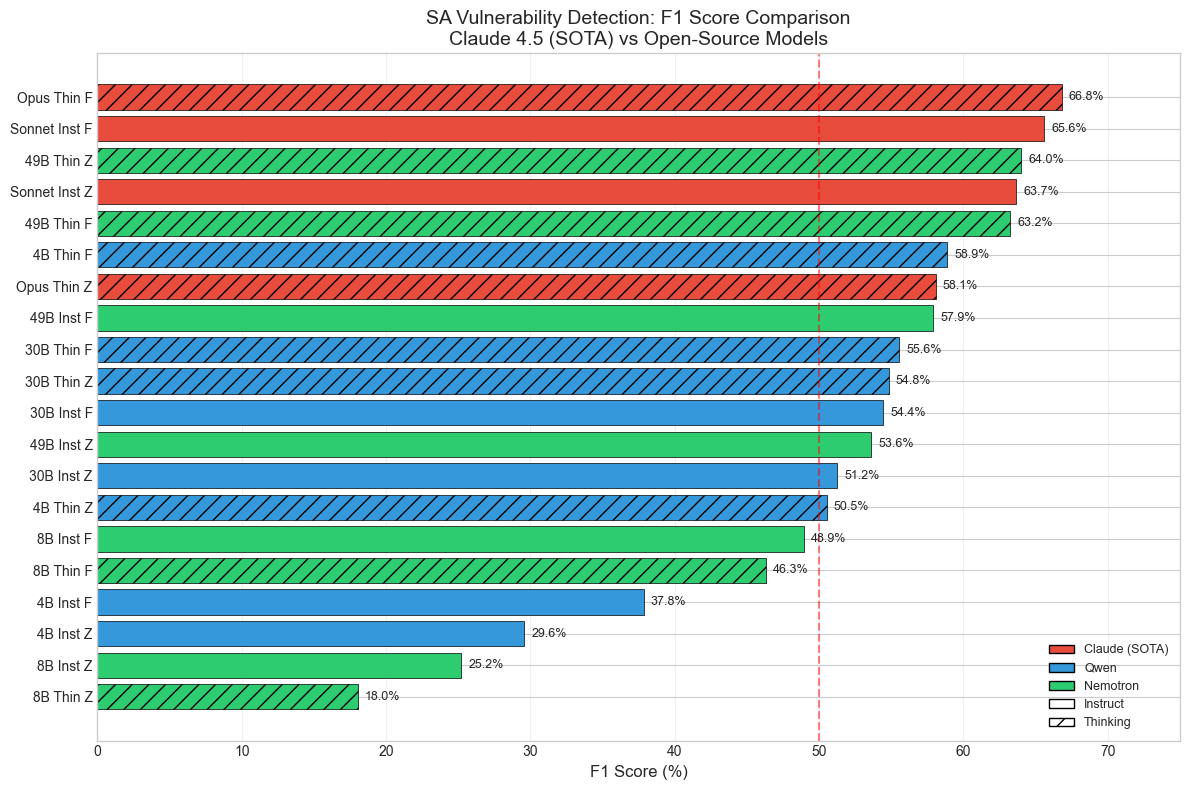

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_sota/sota_f1_comparison.png


In [6]:
# Color mapping
FAMILY_COLORS = {
    'Claude': '#e74c3c',   # Red for Claude
    'Qwen': '#3498db',     # Blue for Qwen
    'Nemotron': '#2ecc71', # Green for Nemotron
}

# Prepare data for bar chart
plot_df = combined_df.sort_values('f1_pct', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart
y_pos = range(len(plot_df))
colors = [FAMILY_COLORS.get(f, 'gray') for f in plot_df['model_family']]

# Add hatching for thinking mode
bars = ax.barh(y_pos, plot_df['f1_pct'], color=colors, edgecolor='black', linewidth=0.5)

# Add hatch pattern for thinking mode
for i, (bar, mode) in enumerate(zip(bars, plot_df['mode'])):
    if mode == 'thinking':
        bar.set_hatch('//')

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['label'], fontsize=10)
ax.set_xlabel('F1 Score (%)', fontsize=12)
ax.set_title('SA Vulnerability Detection: F1 Score Comparison\nClaude 4.5 (SOTA) vs Open-Source Models', fontsize=14)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, plot_df['f1_pct'])):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=9)

# Add 50% reference line (random baseline)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Random baseline (50%)')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='Claude (SOTA)'),
    mpatches.Patch(facecolor='#3498db', edgecolor='black', label='Qwen'),
    mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='Nemotron'),
    mpatches.Patch(facecolor='white', edgecolor='black', label='Instruct'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='Thinking'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlim(0, 75)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'sota_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'sota_f1_comparison.png'}")

## 6. Visualization: Precision vs Recall Trade-off

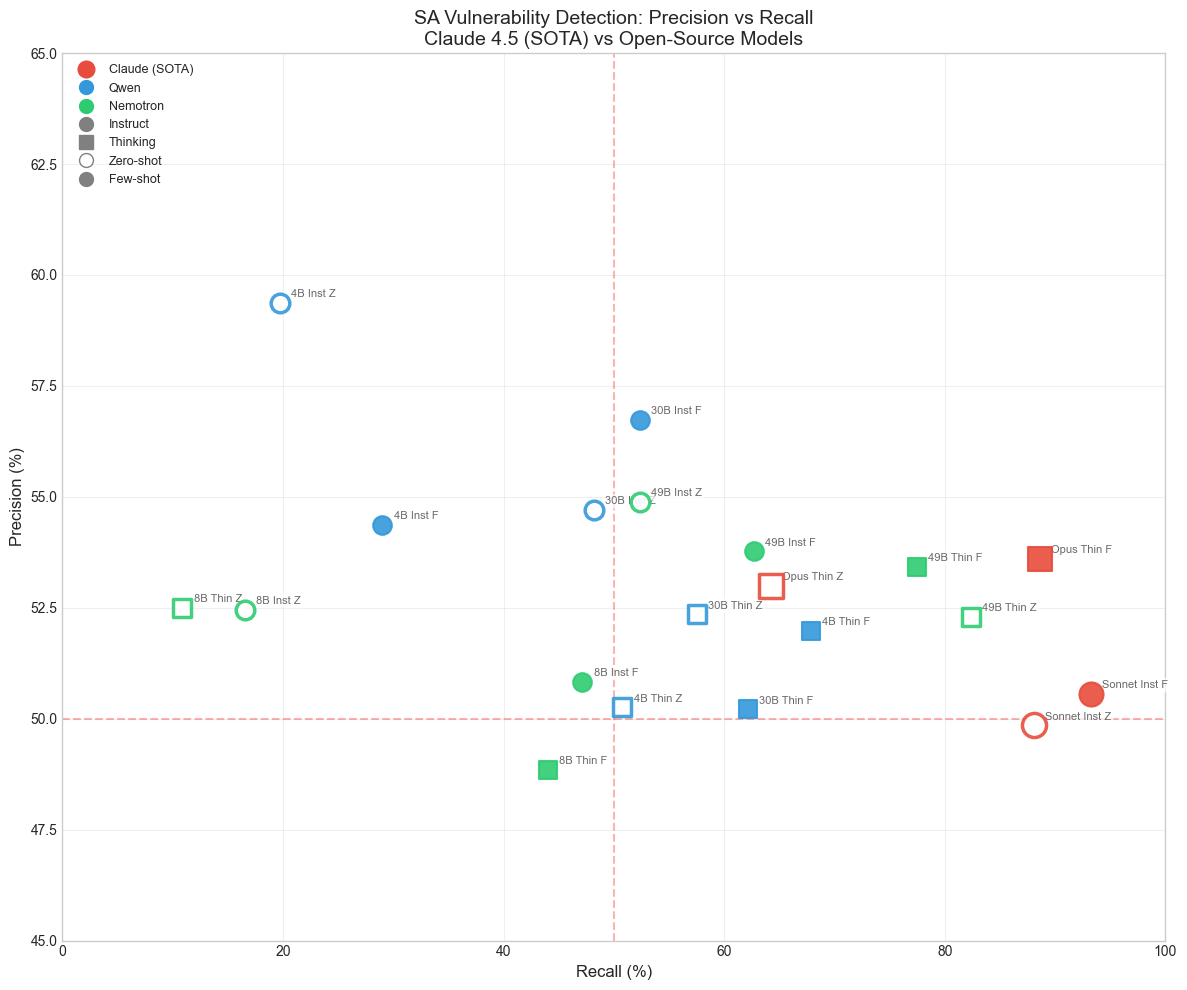

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_sota/sota_precision_recall.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each model
for _, row in combined_df.iterrows():
    color = FAMILY_COLORS.get(row['model_family'], 'gray')
    marker = 's' if row['mode'] == 'thinking' else 'o'
    
    # Fill based on prompting
    if row['prompting'] == 'zero-shot':
        facecolor = 'white'
        edgewidth = 2.5
    else:
        facecolor = color
        edgewidth = 1.5
    
    # Larger markers for SOTA
    size = 300 if row['model_family'] == 'Claude' else 180
    
    ax.scatter(row['recall_pct'], row['precision_pct'], 
               marker=marker, s=size,
               facecolors=facecolor, edgecolors=color, 
               linewidths=edgewidth, zorder=5, alpha=0.9)
    
    # Add label
    ax.annotate(row['label'], (row['recall_pct'], row['precision_pct']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8, color='dimgray',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                          edgecolor='none', alpha=0.7))

# Add 50% reference lines
ax.axhline(y=50, color='red', linestyle='--', alpha=0.3)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.3)

# Labels
ax.set_xlabel('Recall (%)', fontsize=12)
ax.set_ylabel('Precision (%)', fontsize=12)
ax.set_title('SA Vulnerability Detection: Precision vs Recall\nClaude 4.5 (SOTA) vs Open-Source Models', fontsize=14)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
           markeredgecolor='#e74c3c', markersize=12, label='Claude (SOTA)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
           markeredgecolor='#3498db', markersize=10, label='Qwen'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
           markeredgecolor='#2ecc71', markersize=10, label='Nemotron'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='gray', markersize=10, label='Instruct'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markeredgecolor='gray', markersize=10, label='Thinking'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='gray', markersize=10, linewidth=2, label='Zero-shot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='gray', markersize=10, label='Few-shot'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.set_xlim(0, 100)
ax.set_ylim(45, 65)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'sota_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'sota_precision_recall.png'}")

## 7. Key Findings Summary

In [8]:
# Summary statistics by model family
summary_by_family = combined_df.groupby('model_family').agg({
    'accuracy_pct': ['mean', 'max'],
    'f1_pct': ['mean', 'max'],
    'recall_pct': ['mean', 'max'],
    'precision_pct': ['mean', 'max']
}).round(2)

print("="*80)
print("SUMMARY BY MODEL FAMILY")
print("="*80)
print(summary_by_family)

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Best models
best_f1 = combined_df.loc[combined_df['f1_pct'].idxmax()]
best_acc = combined_df.loc[combined_df['accuracy_pct'].idxmax()]

print(f"\n1. BEST F1 SCORE: {best_f1['label']} ({best_f1['model_family']})")
print(f"   F1: {best_f1['f1_pct']:.2f}%, Accuracy: {best_f1['accuracy_pct']:.2f}%")

print(f"\n2. BEST ACCURACY: {best_acc['label']} ({best_acc['model_family']})")
print(f"   Accuracy: {best_acc['accuracy_pct']:.2f}%, F1: {best_acc['f1_pct']:.2f}%")

# Claude vs best open-source
claude_best = combined_df[combined_df['model_family'] == 'Claude']['f1_pct'].max()
open_best = combined_df[combined_df['model_family'] != 'Claude']['f1_pct'].max()
delta = claude_best - open_best

print(f"\n3. SOTA ADVANTAGE:")
print(f"   Claude best F1: {claude_best:.2f}%")
print(f"   Open-source best F1: {open_best:.2f}%")
print(f"   Delta: {delta:+.2f}%")

# Recall analysis
print(f"\n4. RECALL ANALYSIS (vulnerability detection rate):")
claude_recall = combined_df[combined_df['model_family'] == 'Claude']['recall_pct'].mean()
open_recall = combined_df[combined_df['model_family'] != 'Claude']['recall_pct'].mean()
print(f"   Claude avg recall: {claude_recall:.2f}%")
print(f"   Open-source avg recall: {open_recall:.2f}%")
print(f"   Claude tends to predict 'vulnerable' more often (higher false positive rate)")

print(f"\n5. TASK DIFFICULTY CONFIRMATION:")
print(f"   All models achieve ~50-56% accuracy (near random)")
print(f"   Confirms vulnerability detection is challenging for LLMs")

SUMMARY BY MODEL FAMILY
             accuracy_pct        f1_pct        recall_pct         \
                     mean    max   mean    max       mean    max   
model_family                                                       
Claude              52.59  55.96  63.53  66.80      83.55  93.26   
Nemotron            52.37  55.21  47.15  63.98      49.19  82.38   
Qwen                52.69  56.22  49.11  58.88      48.45  67.88   

             precision_pct         
                      mean    max  
model_family                       
Claude               51.75  53.61  
Nemotron             52.38  54.89  
Qwen                 53.75  59.38  

KEY FINDINGS

1. BEST F1 SCORE: Opus Thin F (Claude)
   F1: 66.80%, Accuracy: 55.96%

2. BEST ACCURACY: 30B Inst F (Qwen)
   Accuracy: 56.22%, F1: 54.45%

3. SOTA ADVANTAGE:
   Claude best F1: 66.80%
   Open-source best F1: 63.98%
   Delta: +2.81%

4. RECALL ANALYSIS (vulnerability detection rate):
   Claude avg recall: 83.55%
   Open-source avg re

In [9]:
# Save combined data
combined_df.to_csv(ANALYSIS_DIR / 'sota_comparison_combined.csv', index=False)
print(f"\nSaved combined data: {ANALYSIS_DIR / 'sota_comparison_combined.csv'}")

# Save comparison table
comparison_table.to_csv(ANALYSIS_DIR / 'sota_comparison_table.csv', index=False)
print(f"Saved comparison table: {ANALYSIS_DIR / 'sota_comparison_table.csv'}")

print("\nGenerated files:")
for f in sorted(ANALYSIS_DIR.glob('*')):
    print(f"  - {f.name}")


Saved combined data: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_sota/sota_comparison_combined.csv
Saved comparison table: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_sota/sota_comparison_table.csv

Generated files:
  - sota_comparison_combined.csv
  - sota_comparison_table.csv
  - sota_f1_comparison.png
  - sota_precision_recall.png
